# Kinematic Simulation of a Differential Drive Robot

# Introduction

Well what's a Differential Drive? It's basically a method used to move robots in which two independent wheels are mounted on a common axis. A differential is maintained between the two wheels.
* If both the wheels spin forward at the same time, the robot moves straight.
* If one spins faster than the other, it turns in the direction of the slower wheel.
* If they spin in opposite directions at the same speed, it spins **in place**.

# The Math (Most Important Part)

Alright so before simulating a Differential Drive Robot, we have to study the math behind it. Here are few things to keep in mind.

### Position
    First, off, we need the definition of position in 2D space for the robot.
    The position of the robot is given by the vector State = Transpose([x, y, theta])

### Input
    The input controls (commands to the robot) are -
    v: Linear Velocity (Forward Speed)
    w: Angular Velocity (Turning Speed)

### State Change
    The kinematic equations that describe how the state changes over time (x_dot, y_dot, theta_dot) based on our inputs are-
    
    x_dot = v * cos(theta)
    y_dot = v * sin(theta)
    theta_dot = w

# Defining the Robot Model

In [1]:
# First I'm just going to import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import math

# Set up matplotlib for nice rendering in Jupyter
%matplotlib inline

In [2]:
# Now I'm going to write a function that updates the robot's pos based on velocity inputs
def update_state(x, y, theta, v, w, dt):
    # Just integrate state change equations to get these
    next_x = x + (v * math.cos(theta)) * dt
    next_y = y + (v * math.sin(theta)) * dt
    next_theta = theta + w * dt

    # But let's maintain the bijection, we don't want theta outside (-pi/2, pi/2)
    next_theta = math.atan2(math.sin(next_theta), math.cos(next_theta))

    return next_x, next_y, next_theta

# The Controller - The Brain

Now that I'm done making that function, the next thing I need to address is how the robot will know where the point is and approach it. For this a closed feedback loop will do the job. The robot needs to know two things at all times -
* How far it is from the goal
* Which distance it's facing and how to turn to face the goal

In [3]:
# This is a function to calculate the necessary input velocities to reach the goal
# Also, I'll be using just a Proportional Controller
def calculate_control_commands(x, y, theta, x_goal, y_goal):
    # Initialise Gains
    Kp_linear = 0.5
    Kp_angular = 2.0

    # First it needs to know distance from the goal
    distance_error = math.hypot(x-x_goal, y-y_goal)

    # Next it needs to know which direction to move in
    desired_heading = math.atan2(y_goal-y, x_goal-x)

    # Now it needs to know diffence in direction
    heading_error = desired_heading - theta
    heading_error = math.atan2(math.sin(heading_error), math.cos(heading_error))

    # Then generate the velocity commands
    v = Kp_linear * distance_error
    w = Kp_angular * heading_error

    # This is an extra thing I wanna add to simulate real world hardware limitations...
    # I'm going to cap the velocity at 1m/s
    v = min(v, 1.0)

    return v, w, distance_error

# Designing the Simulation Loop

Now that all this is done, we need to use these in a loop which ends when the robot reaches the end point.

In [4]:
# Initialise Conditions
x, y, theta = 0.0, 0.0, 0.0  # Starting at origin, facing right
x_goal, y_goal = 5.0, 5.0    # Target point

dt = 0.1 # Step duration of time
tolerance = 0.1 # Stop when we are within 0.1 meters of the goal

In [5]:
# Lists to store history for plotting
x_history = [x]
y_history = [y]

print("Starting simulation...")

while True:
    # Get commands from controller
    v, omega, distance = calculate_control_commands(x, y, theta, x_goal, y_goal)
    
    # Check if we reached the goal
    if distance < tolerance:
        print("Goal Reached!")
        break
        
    # Update the robot's state
    x, y, theta = update_state(x, y, theta, v, omega, dt)
    
    # Save history
    x_history.append(x)
    y_history.append(y)

Starting simulation...
Goal Reached!


I guess it's worked pretty well. Now I think it's better to look at it once so I'm going to try to plot it using matplotlib.

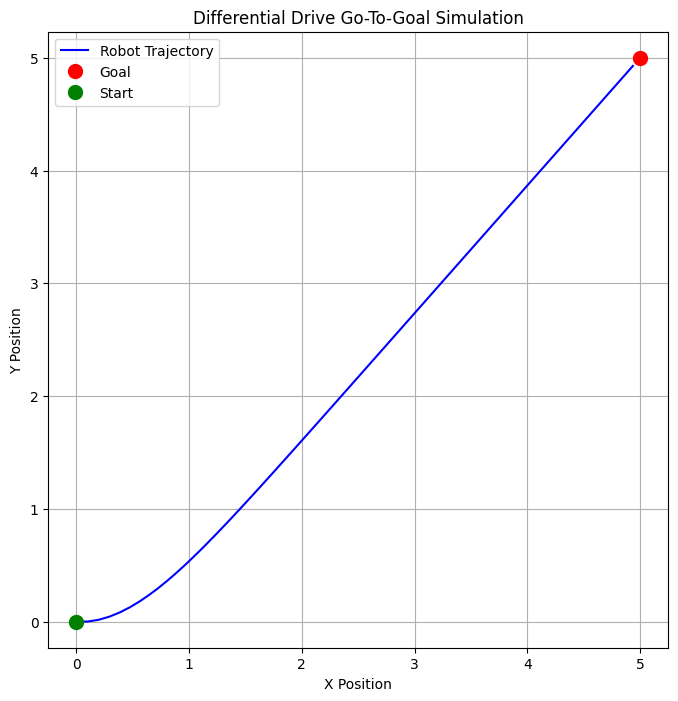

In [6]:
plt.figure(figsize=(8, 8))
plt.plot(x_history, y_history, label="Robot Trajectory", color='b')
plt.plot(x_goal, y_goal, 'ro', label="Goal", markersize=10)
plt.plot(0, 0, 'go', label="Start", markersize=10)

plt.title("Differential Drive Go-To-Goal Simulation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensures x and y scales are identical
plt.show()